## **1. Análisis Exploratorio de Datos (EDA)**
**Objetivo:** comprender la estructura del dataset musical, identificar patrones, detectar anomalías y limpiar los datos para preparar el terreno hacia el modelado.

---
### **1.1 Carga y limpieza inicial de los datos**

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de estilo
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Carpeta de salida para figuras
os.makedirs('figuras/EDA', exist_ok=True)

# Carga del dataset
df = pd.read_csv('data/SpotifyFeatures.csv')

# Vista previa
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [2]:
# Información general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  str    
 1   artist_name       232725 non-null  str    
 2   track_name        232724 non-null  str    
 3   track_id          232725 non-null  str    
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  str    
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  str    
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    232725 non-nu

Tras una primera inspección con `.info()`, destacamos los siguientes puntos clave sobre la calidad del dato:

* **Volumen:** el dataset contiene **232725 entradas** y 18 columnas.
* **Completitud:** no existen valores nulos, lo que elimina la necesidad de técnicas de imputación.
* **Tipología:**
    * **Variables numéricas:** (`float64`, `int64`) como *acousticness* o *popularity*.
    * **Variables categóricas:** (`str`) como *key*, *mode* y *genre*.
    
Las variables categóricas requerirán una transformación numérica (*encoding*) en la fase de ingeniería de características, ya que los algoritmos de *machine learning* operan exclusivamente con vectores numéricos.

In [3]:
# Estadísticas descriptivas de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,232725.0,41.127502,18.189948,0.00000,29.0000,43.000000,55.0000,100.000
acousticness,232725.0,0.368560,0.354768,0.00000,0.0376,0.232000,0.7220,0.996
danceability,232725.0,0.554364,0.185608,0.05690,0.4350,0.571000,0.6920,0.989
duration_ms,232725.0,235122.339306,118935.909299,15387.00000,182857.0000,220427.000000,265768.0000,5552917.000
energy,232725.0,0.570958,0.263456,0.00002,0.3850,0.605000,0.7870,0.999
instrumentalness,232725.0,0.148301,0.302768,0.00000,0.0000,0.000044,0.0358,0.999
liveness,232725.0,0.215009,0.198273,0.00967,0.0974,0.128000,0.2640,1.000
loudness,232725.0,-9.569885,5.998204,-52.45700,-11.7710,-7.762000,-5.5010,3.744
speechiness,232725.0,0.120765,0.185518,0.02220,0.0367,0.050100,0.1050,0.967
tempo,232725.0,117.666585,30.898907,30.37900,92.9590,115.778000,139.0540,242.903


Las estadísticas revelan una **disparidad significativa en las magnitudes** de las variables, lo cual es crítico para modelos basados en distancia:

* **Rango 0-1:** `acousticness`, `danceability`, `energy`, entre otras.
* **Rango 0-100:** `popularity`.
* **Escala logarítmica:** `loudness` (dB) oscila entre -52 y 3.7.
* **Gran magnitud:** `duration_ms` tiene una media de ~235k y máximos de 5.5M.

Esta varianza confirma la **necesidad imperativa de aplicar técnicas de normalización o estandarización**. Sin normalización, la variable `duration_ms` dominaría completamente el cálculo de la distancia euclídea, haciendo que el modelo ignore características sutiles como la `danceability`.

#### Detección y eliminación de duplicados

Dado que el dataset agrega canciones procedentes de distintas *playlists* temáticas de Spotify, una misma canción popular puede aparecer etiquetada bajo múltiples géneros. Mantener estas copias provocaría dos problemas:

1. El análisis estadístico quedaría distorsionado por la sobrerrepresentación de canciones populares.
2. El modelo KNN podría recomendar la misma canción varias veces con distintas etiquetas de género, arruinando la experiencia del usuario.

**Hipótesis:** existen múltiples filas compartiendo el mismo `track_id`.

In [4]:
# Calculo de duplicados
total_filas = df.shape[0]
canciones_unicas = df['track_id'].nunique()
canciones_duplicadas = total_filas - canciones_unicas

print(f"Total de registros: {total_filas}")
print(f"Canciones únicas (track_id): {canciones_unicas}")
print(f"Canciones duplicadas: {canciones_duplicadas}")

# Mostrar evidencia. Si hay canciones duplicadas, buscamos un ID repetido para visualizarlo
if canciones_duplicadas > 0:
    # Obtenemos el ID más frecuente
    id_repetido = df['track_id'].value_counts().idxmax()
    print(f"\nEjemplo de duplicidad para el track_id: {id_repetido}")
    display(df[df['track_id'] == id_repetido])

Total de registros: 232725
Canciones únicas (track_id): 176774
Canciones duplicadas: 55951

Ejemplo de duplicidad para el track_id: 0wY9rA9fJkuESyYm9uzVK5


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
1804,Alternative,SiR,D'Evils,0wY9rA9fJkuESyYm9uzVK5,63,0.00558,0.784,171818,0.586,0.000286,C#,0.106,-3.417,Major,0.187,132.169,4/4,0.656
68204,Hip-Hop,SiR,D'Evils,0wY9rA9fJkuESyYm9uzVK5,67,0.00558,0.784,171818,0.586,0.000286,C#,0.106,-3.417,Major,0.187,132.169,4/4,0.656
77892,Children’s Music,SiR,D'Evils,0wY9rA9fJkuESyYm9uzVK5,66,0.00558,0.784,171818,0.586,0.000286,C#,0.106,-3.417,Major,0.187,132.169,4/4,0.656
93893,Indie,SiR,D'Evils,0wY9rA9fJkuESyYm9uzVK5,67,0.00558,0.784,171818,0.586,0.000286,C#,0.106,-3.417,Major,0.187,132.169,4/4,0.656
115551,Rap,SiR,D'Evils,0wY9rA9fJkuESyYm9uzVK5,67,0.00558,0.784,171818,0.586,0.000286,C#,0.106,-3.417,Major,0.187,132.169,4/4,0.656
149893,Pop,SiR,D'Evils,0wY9rA9fJkuESyYm9uzVK5,67,0.00558,0.784,171818,0.586,0.000286,C#,0.106,-3.417,Major,0.187,132.169,4/4,0.656
152677,R&B,SiR,D'Evils,0wY9rA9fJkuESyYm9uzVK5,67,0.00558,0.784,171818,0.586,0.000286,C#,0.106,-3.417,Major,0.187,132.169,4/4,0.656
192273,Soul,SiR,D'Evils,0wY9rA9fJkuESyYm9uzVK5,67,0.00558,0.784,171818,0.586,0.000286,C#,0.106,-3.417,Major,0.187,132.169,4/4,0.656


La hipótesis se confirma: existen **55.951 duplicados**. El ejemplo muestra cómo una misma canción aparece registrada bajo hasta 8 géneros distintos manteniendo valores acústicos idénticos.

**Decisión:** se eliminan los duplicados conservando únicamente la primera aparición de cada `track_id`.

> **Nota metodológica:** a partir de este punto, los análisis que dependan de la distribución de géneros (secciones 1.3 categórica y 1.5) se realizarán sobre `df` (dataset bruto), no sobre `df_clean`. El motivo es que al deduplicar con `keep='first'` se introduce un sesgo en la distribución de géneros: solo se conserva el primer género asignado a cada canción, perdiendo la representación real del catálogo. Para cualquier análisis que no dependa del género, se usará `df_clean`.

In [5]:
# Eliminación de duplicados manteniendo la primera aparición
df_clean = df.drop_duplicates(subset=['track_id'], keep='first')

# Verificación de la eliminación de duplicados
print(f"Dimensiones antes: {df.shape}")
print(f"Dimensiones después: {df_clean.shape}")

Dimensiones antes: (232725, 18)
Dimensiones después: (176774, 18)


#### Detección y filtrado de *outliers* en duración

Con el dataset ya sin duplicados, se verifican valores anómalos en las variables numéricas.

El análisis del **tempo** revela un rango correcto (mín. ~30 BPM, máx. ~243 BPM), por lo que no requiere intervención. Se analiza a continuación la variable `duration_ms`, donde se sospecha la presencia de pistas atípicas (sesiones de DJ, grabaciones en directo, audio ambiental) que no deberían compararse con canciones convencionales.

In [6]:
# Verificación del rango de tempo
print(f"Tempo mínimo: {df_clean['tempo'].min():.3f} BPM")
print(f"Tempo máximo: {df_clean['tempo'].max():.3f} BPM")

Tempo mínimo: 30.379 BPM
Tempo máximo: 242.903 BPM


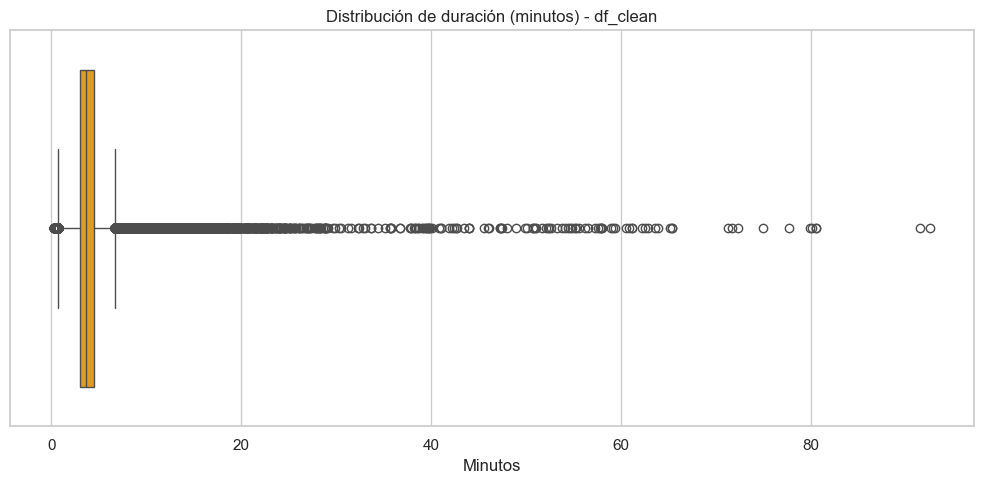

Canciones de más de 10 minutos: 2052


In [7]:
# Visualización de la distribución de duración
duration_mins = df_clean['duration_ms'] / 60000

plt.figure(figsize=(10, 5))
sns.boxplot(x=duration_mins, color='orange')
plt.title('Distribución de duración (minutos) - df_clean')
plt.xlabel('Minutos')
plt.tight_layout()
plt.savefig('figuras/EDA/boxplot_duracion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Canciones de más de 10 minutos: {len(df_clean[duration_mins > 10])}")

In [8]:
# Filtrado por duración
MIN_DURATION = 30_000   # 30 segundos
MAX_DURATION = 600_000  # 10 minutos

df_final = df_clean[
    (df_clean['duration_ms'] >= MIN_DURATION) &
    (df_clean['duration_ms'] <= MAX_DURATION)
]

print(f"Dimensiones antes  (df_clean): {df_clean.shape}")
print(f"Dimensiones finales (df_final): {df_final.shape}")
print(f"Registros eliminados: {len(df_clean) - len(df_final)}")

Dimensiones antes  (df_clean): (176774, 18)
Dimensiones finales (df_final): (174582, 18)
Registros eliminados: 2192


El diagrama de caja muestra una cola de *outliers* extremos hacia la derecha. Existen más de 2.000 pistas que superan los 10 minutos.

**Decisión:** se establece un filtro con mínimo de 30 segundos (para excluir fragmentos o intros) y máximo de 10 minutos, homogeneizando la muestra y evitando que la duración domine el cálculo de similitud.

In [9]:
# Exportación del dataset limpio para las fases posteriores
df_final.to_csv('data/SpotifyFeatures_cleaned.csv', index=False)
print("Archivo 'data/SpotifyFeatures_cleaned.csv' guardado exitosamente.")

Archivo 'data/SpotifyFeatures_cleaned.csv' guardado exitosamente.


---
### **1.2 Análisis de distribuciones**

#### Variables numéricas continuas  *(sobre `df_clean`)*

Se analiza la forma de la distribución de las principales características acústicas. Esto es relevante de cara al escalado posterior: distribuciones muy asimétricas pueden requerir transformaciones adicionales.

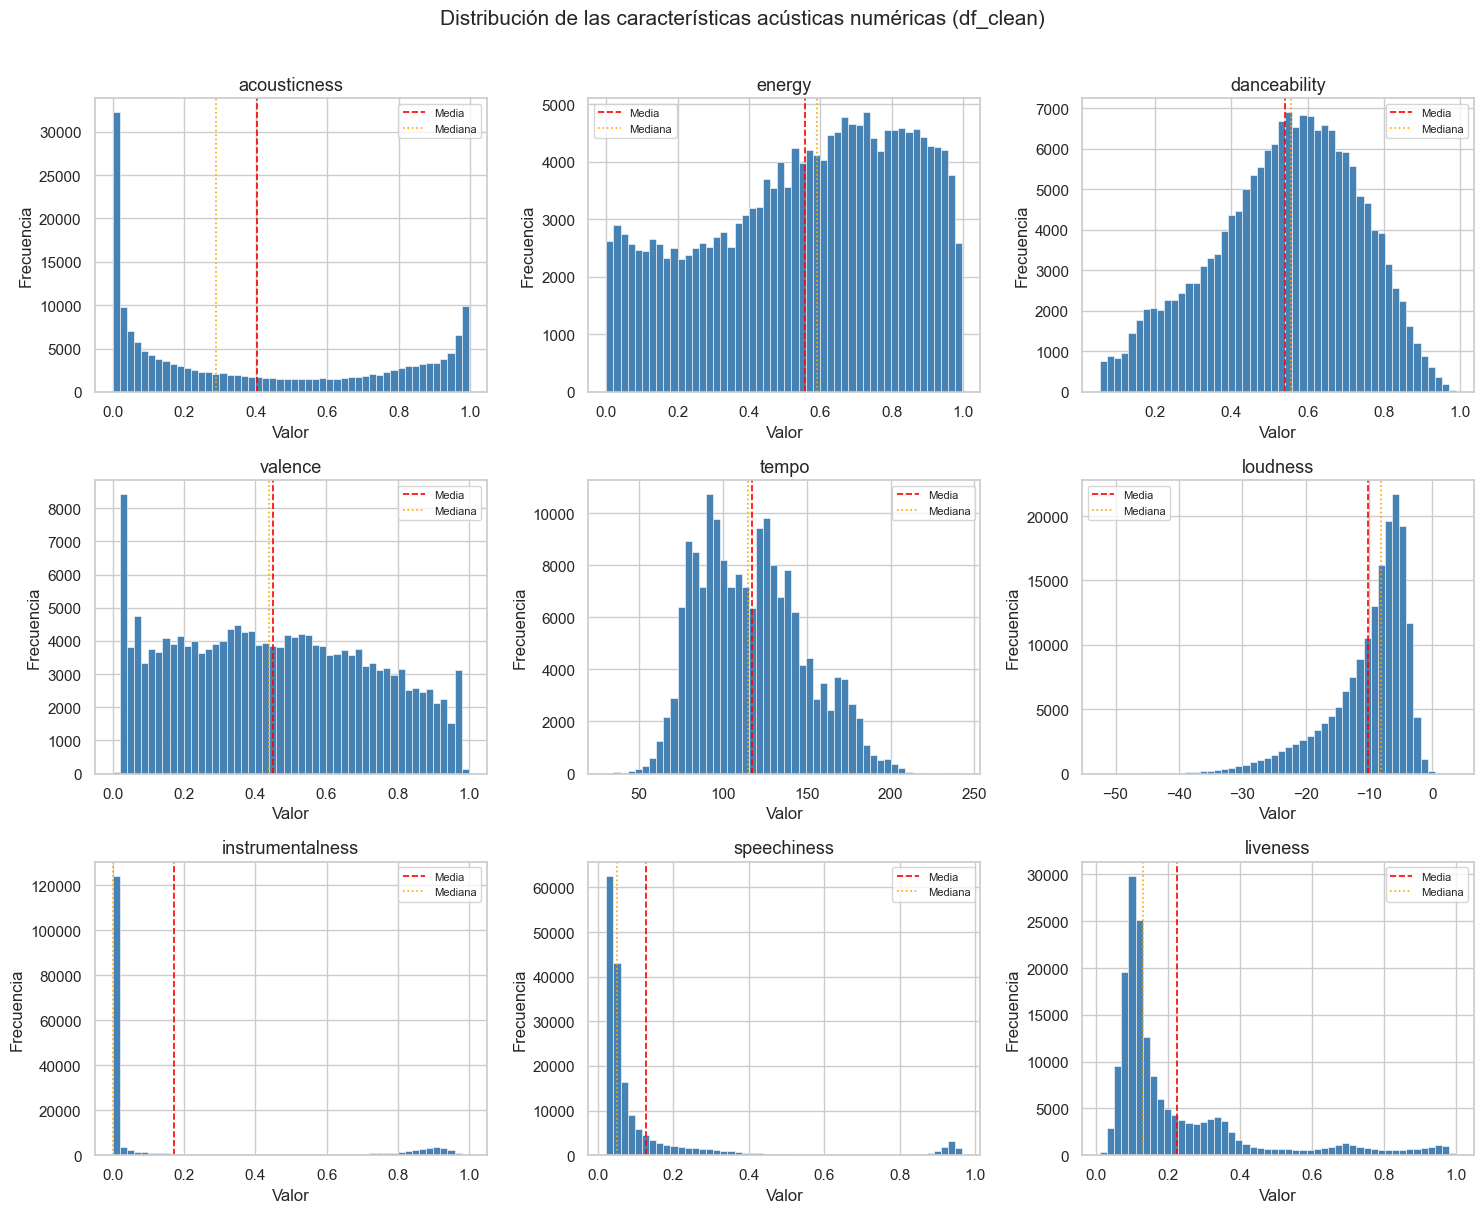

In [10]:
# Grid de histogramas de las características acústicas
features_continuas = ['acousticness', 'energy', 'danceability', 'valence',
                       'tempo', 'loudness', 'instrumentalness', 'speechiness', 'liveness']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features_continuas):
    axes[i].hist(df_clean[feature], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].set_title(feature, fontsize=13)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(df_clean[feature].mean(),   color='red',    linestyle='--', linewidth=1.2, label='Media')
    axes[i].axvline(df_clean[feature].median(), color='orange', linestyle=':',  linewidth=1.2, label='Mediana')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de las características acústicas numéricas (df_clean)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('figuras/EDA/histogramas_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:**

* `energy` y `danceability` presentan distribuciones aproximadamente simétricas, lo que indica una buena representación del espacio de características.
* `instrumentalness` y `speechiness` muestran distribuciones fuertemente asimétricas con concentración en valores cercanos a cero, coherente con un catálogo dominado por canciones vocales.
* `liveness` también se concentra en valores bajos, reflejando que la mayoría de canciones son grabaciones de estudio.
* `loudness` presenta una distribución aproximadamente normal con cola izquierda, confirmando que la mayoría de canciones se producen en rangos de volumen similares.

#### Variables categóricas  *(sobre `df` bruto)*

> **Nota metodológica:** este análisis se realiza sobre el dataset **original sin deduplicar** (`df`) cuando analizamos los géneros. Si se usase `df_clean`, su distribución estaría sesgada por el criterio `keep='first'`: solo se conservaría el primer género asignado a cada canción, distorsionando la representación real del catálogo.

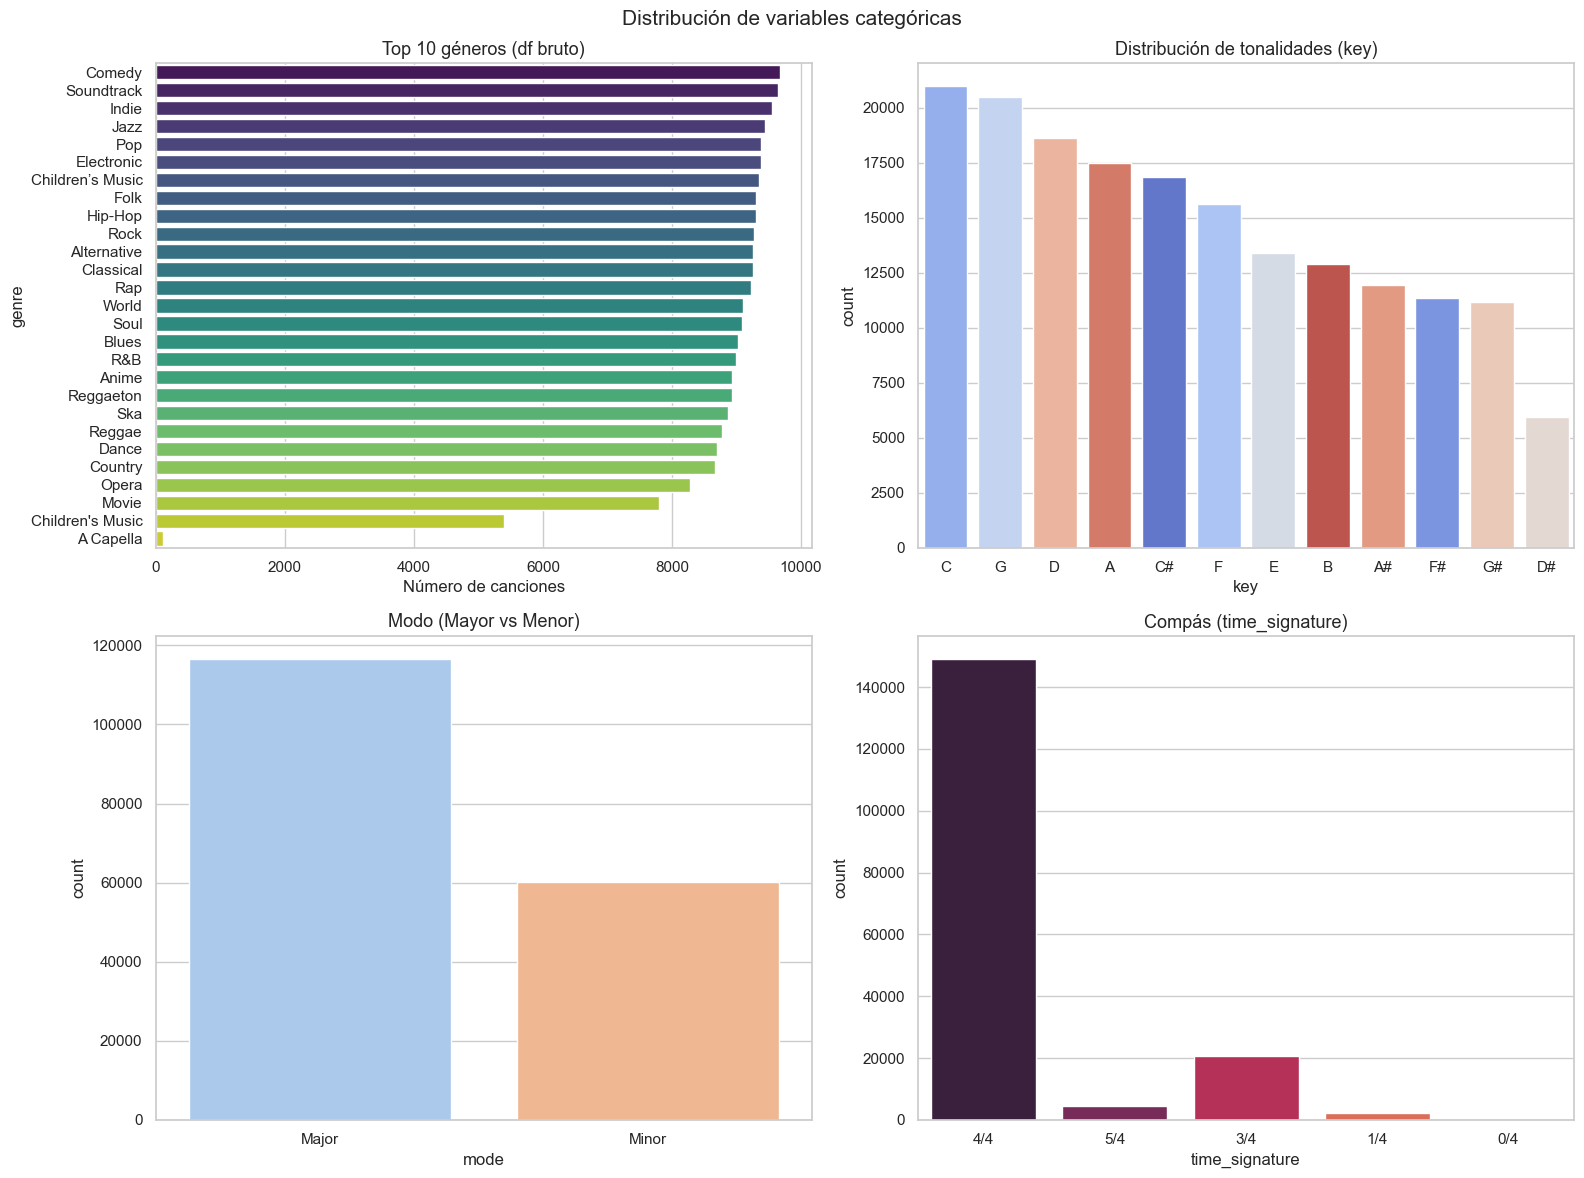

In [11]:
# Grid 2x2: género, tonalidad, modo y compás
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 10 géneros
top_genres = df['genre'].value_counts()
sns.barplot(x=top_genres.values, y=top_genres.index,
            hue=top_genres.index, legend=False, ax=ax[0, 0], palette='viridis')
ax[0, 0].set_title('Top 10 géneros (df bruto)', fontsize=13)
ax[0, 0].set_xlabel('Número de canciones')

# 2. Tonalidades (key)
sns.countplot(data=df_clean, x='key', hue='key', legend=False, ax=ax[0, 1],
              order=df_clean['key'].value_counts().index, palette='coolwarm')
ax[0, 1].set_title('Distribución de tonalidades (key)', fontsize=13)

# 3. Modo (Mayor / Menor)
sns.countplot(data=df_clean, x='mode', hue='mode', legend=False,
              ax=ax[1, 0], palette='pastel')
ax[1, 0].set_title('Modo (Mayor vs Menor)', fontsize=13)

# 4. Compás (time_signature)
sns.countplot(data=df_clean, x='time_signature', hue='time_signature', legend=False,
              ax=ax[1, 1], palette='rocket')
ax[1, 1].set_title('Compás (time_signature)', fontsize=13)

plt.suptitle('Distribución de variables categóricas', fontsize=15)
plt.tight_layout()
# plt.savefig('figuras/EDA/distribucion_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

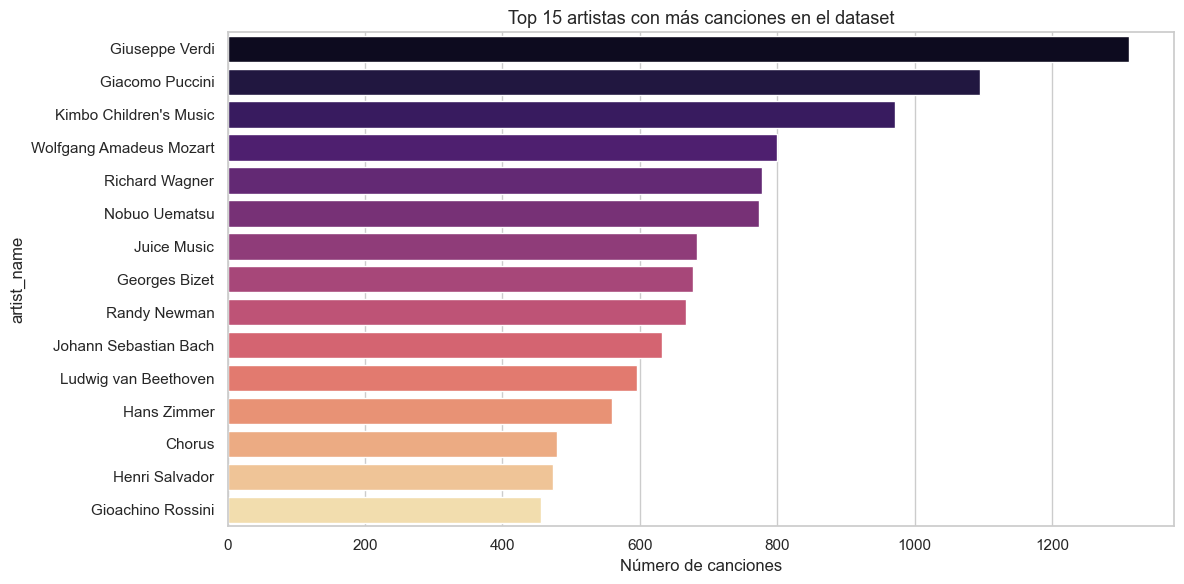

In [12]:
# Top 15 artistas con más canciones
plt.figure(figsize=(12, 6))
top_artists = df_clean['artist_name'].value_counts().head(15)
sns.barplot(x=top_artists.values, y=top_artists.index,
            hue=top_artists.index, legend=False, palette='magma')
plt.title('Top 15 artistas con más canciones en el dataset', fontsize=13)
plt.xlabel('Número de canciones')
plt.tight_layout()
plt.savefig('figuras/EDA/top_artistas.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:**

1. **Sesgo de géneros:** ciertos géneros dominan el dataset. El modelo tendrá mayor representación de esos estilos y será potencialmente más preciso al recomendarlos frente a los géneros minoritarios.
2. **Validación musical en tonalidades:** el predominio de **Do (C)** y **Sol (G)** coincide con las tonalidades más empleadas en la composición popular occidental, lo que valida la calidad del dato.
3. **Tendencia al modo mayor:** aproximadamente el 65% de las canciones están en modo mayor, lo que sugiere un catálogo con tendencia hacia sonoridades positivas.
4. **Baja varianza en el compás:** `time_signature` es prácticamente constante en 4/4. Al no aportar diferenciación entre canciones, es candidata firme a ser **eliminada del vector de características** del modelo.

---
### **1.3 Análisis de correlación y relaciones entre variables**  *(sobre `df_clean`)*

**Objetivo:** detectar multicolinealidad entre las variables numéricas. Si dos variables presentan una correlación cercana a ±1, el modelo de distancia estará contando doble esa característica, otorgándole un peso injustificado.

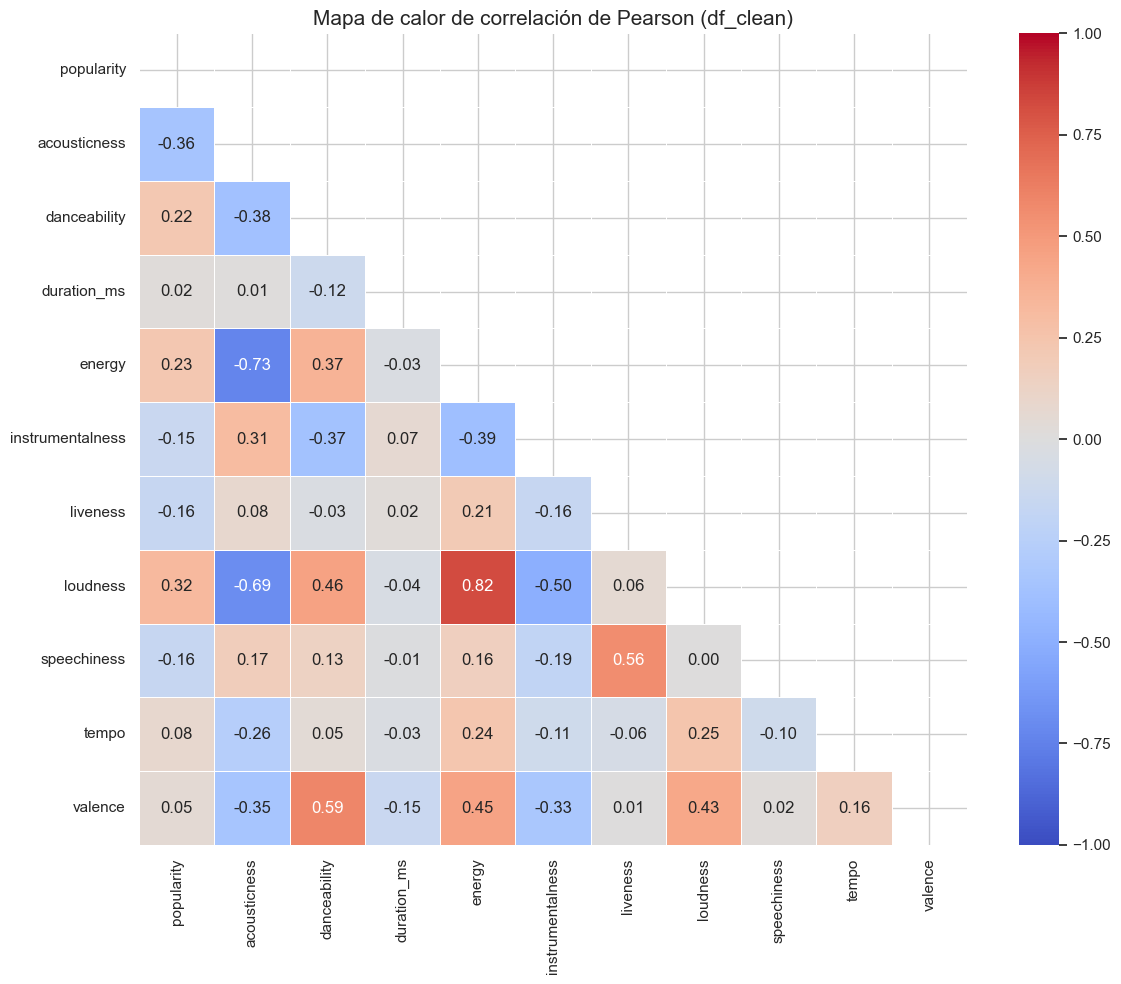

In [13]:
# Selección de columnas numéricas
numeric_cols = ['popularity', 'acousticness', 'danceability', 'duration_ms',
                'energy', 'instrumentalness', 'liveness', 'loudness',
                'speechiness', 'tempo', 'valence']

# Matriz de correlación de Pearson
corr_matrix = df_clean[numeric_cols].corr()

# Máscara para ocultar el triángulo superior (redundante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de calor de correlación de Pearson (df_clean)', fontsize=15)
plt.tight_layout()
plt.savefig('figuras/EDA/heatmap_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

**Hallazgos clave:**

1. **`energy` vs. `loudness` (+0,82):** correlación positiva extremadamente alta. Las canciones con mayor volumen casi siempre tienen mayor energía. Mantener ambas podría otorgar un peso excesivo a la "potencia" sonora en el cálculo de distancias. → **Justifica la evaluación posterior de modelos con PCA.**
2. **`acousticness` vs. `energy` (−0,73):** correlación negativa fuerte y musicalmente lógica: cuanto más acústica es una canción, menos energía electrónica presenta. Esta relación es deseable para diferenciar géneros como folk frente a techno.
3. **`valence` vs. `danceability` (+0,59):** correlación moderada-alta. Las canciones bailables tienden a ser más alegres, pero la relación no es absoluta, por lo que ambas variables aportan matices independientes útiles para el modelo.

**Decisión:** no se elimina ninguna variable en esta fase. Se comparará empíricamente el rendimiento de modelos entrenados sobre la dimensionalidad original frente a modelos con reducción de dimensionalidad mediante PCA.

---
### **1.4 Impacto del género musical en las características de audio**  *(sobre `df` bruto)*

> **Nota metodológica:** igual que en el análisis de distribuciones categóricas, este análisis se realiza sobre el dataset **original sin deduplicar** (`df`) para no introducir el sesgo de género derivado del criterio `keep='first'`.

El objetivo es verificar si el género condiciona el perfil acústico de las canciones. Si los géneros presentan diferencias acústicas significativas, las características de audio por sí solas serán suficientemente discriminativas, lo que justificaría prescindir de la etiqueta de género en el modelo.

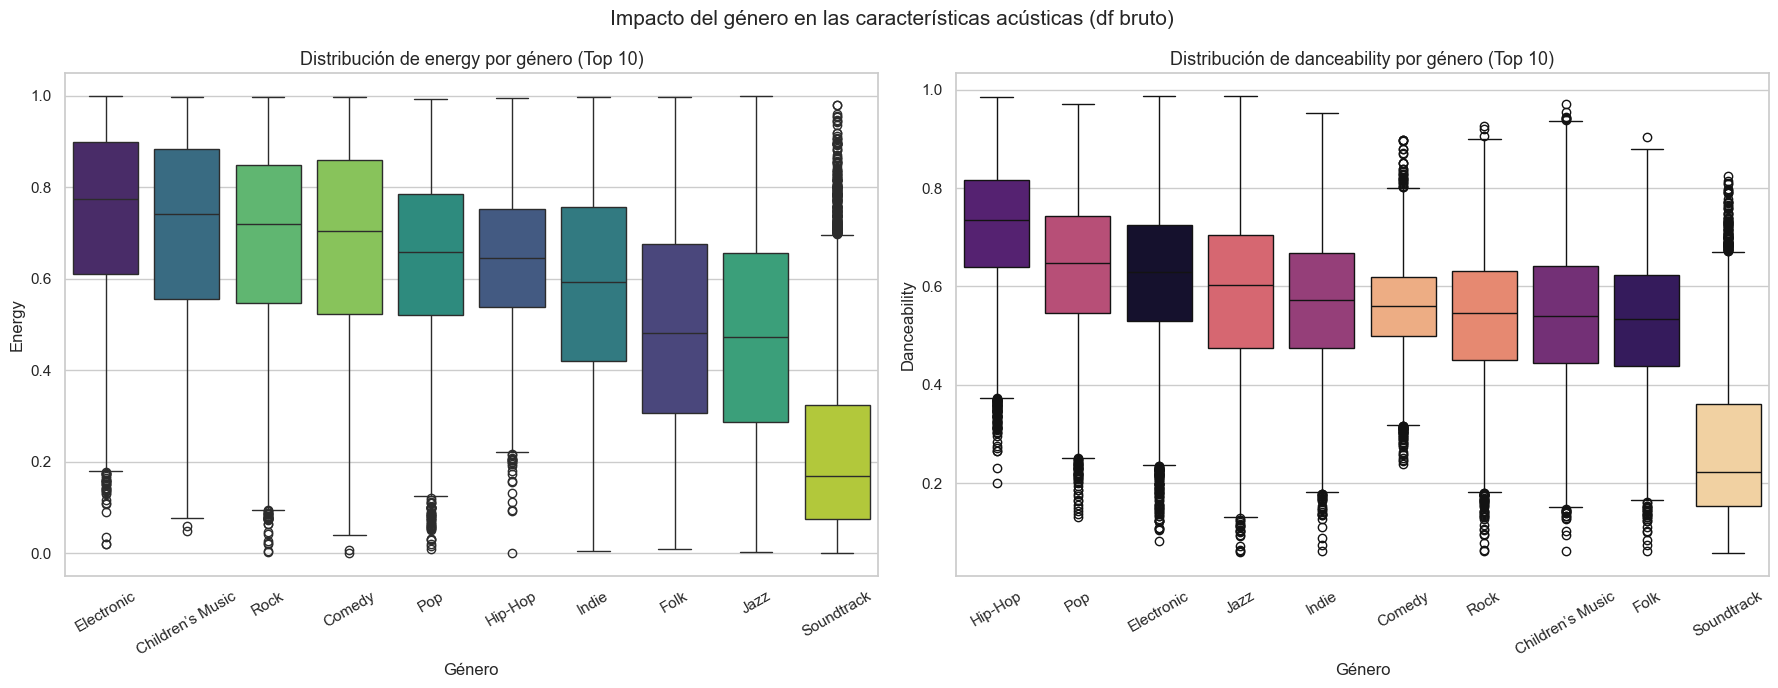

In [14]:
# Limitamos a los Top 10 géneros para mayor legibilidad
top10_genres = df['genre'].value_counts().head(10).index
df_top10 = df[df['genre'].isin(top10_genres)]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Boxplot de energy por género (ordenado por mediana descendente)
order_energy = df_top10.groupby('genre')['energy'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top10, x='genre', y='energy',
            order=order_energy, hue='genre', palette='viridis', ax=axes[0])
axes[0].set_title('Distribución de energy por género (Top 10)', fontsize=13)
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Energy')
axes[0].tick_params(axis='x', rotation=30)

# Boxplot de danceability por género (ordenado por mediana descendente)
order_dance = df_top10.groupby('genre')['danceability'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top10, x='genre', y='danceability',
            order=order_dance, hue='genre', palette='magma', ax=axes[1])
axes[1].set_title('Distribución de danceability por género (Top 10)', fontsize=13)
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Danceability')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Impacto del género en las características acústicas (df bruto)', fontsize=15)
plt.tight_layout()
plt.savefig('figuras/EDA/boxplots_genero.png', dpi=150, bbox_inches='tight')
plt.show()

---
### **1.5 Conclusiones**

El análisis exploratorio ha permitido caracterizar el dataset con rigor y fundamentar las decisiones de preprocesamiento que guiarán las fases posteriores:

|   | Hallazgo | Decisión |
|---|---|---|
| 1 | Dataset original con 232.725 registros, sin valores nulos | Sin imputación necesaria |
| 2 | 55.951 duplicados por `track_id` (canciones en múltiples géneros) | Eliminar con `keep='first'` → `df_clean` (176.774 canciones) |
| 3 | 2.192 pistas con duración anómala (>10 min o <30 s) | Filtrar por duración → `df_final` (174.582 canciones) |
| 4 | Gran disparidad de magnitudes entre variables | Aplicar `StandardScaler` en ingeniería de características |
| 5 | Multicolinealidad entre `energy` y `loudness` (+0,82) | Comparar modelos con dimensionalidad original vs. PCA |
| 6 | `time_signature` casi constante (4/4) → baja varianza | Excluir del vector de características |
| 7 | `genre` inconsistente (multiétiqueta) y no fiable por canción | Excluir del vector de características |
| 8 | Las características acústicas diferencian géneros con solapamiento | Las *features* de audio son suficientemente discriminativas sin depender del género |

El dataset final exportado (`SpotifyFeatures_cleaned.csv`) con **174.582 canciones** y **18 columnas** será el punto de partida para la fase de ingeniería de características.